# Multi-armed bandit 
Using the theory of exploriation and exploitation and taking only 
3 livers which refers to the 3 different veg pizza shops and one is mine which is multinational and had more than 1000 shops in total and the second one is my best competator's who also had similar profile but doesn't had a good coustmer review and the other one is the differnt shops combined 
### This disscription will decide the reward of the shop in general

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Rewards 
will be decided randomly but the description will be play a major role like my shop `90%` of time will give reward number=`1` and competator's will give `60%` of time reward number =`1`
and the others will be like `40%` ot the time reward  number =`1` and remaining time the reward number will be equal to `0`
I assume this will be the good method for it 

# Formula 
Probability theory give a beautiful formula which is $$Q_{n+1} = Q_n + \alpha (R_n - Q_n)$$Breaking Down the Variables
* $Q_{n+1}$ (New Estimate): The updated estimated probability of a payout for a specific arm after pulling it.
* $Q_n$ (Old Estimate): What the algorithm thought the probability was before pulling the arm.
* $\alpha$ (Step Size / Learning Rate): Determines how much the new information overrides the old information. In the Python script earlier, this was calculated as $\frac{1}{n}$, where $n$ is the total number of times that specific arm has been pulled.
* $R_n$ (Reward): The actual outcome of the pull (e.g., 1 for a win, 0 for a loss).
* $(R_n - Q_n)$ (The Error): This is the most crucial part. It calculates the difference between the actual reward and the expected reward.

In [2]:
# Creating the leavers/shops these are going to be classes which stores the probability and the reward 
# and the number of times the customer visited number
# and for the person to visit the shop i am keeping the initial probability to be 
# equal to all so p=1/3
class Shop:
    def __init__(self,reputation):# reputaion is a number which I described earlier
        self.p=1/3
        self.reward = lambda: 1 if np.random.rand() >1-reputation else 0
        self.n = 0
    def update_probability(self,reward):
        self.n += 1
        self.p = self.p + 1/self.n * (reward - self.p)

#My store
shop1 = Shop(0.9)
#Competitor store
shop2 = Shop(0.6)
#Other stores
shop_other = Shop(0.4)
        


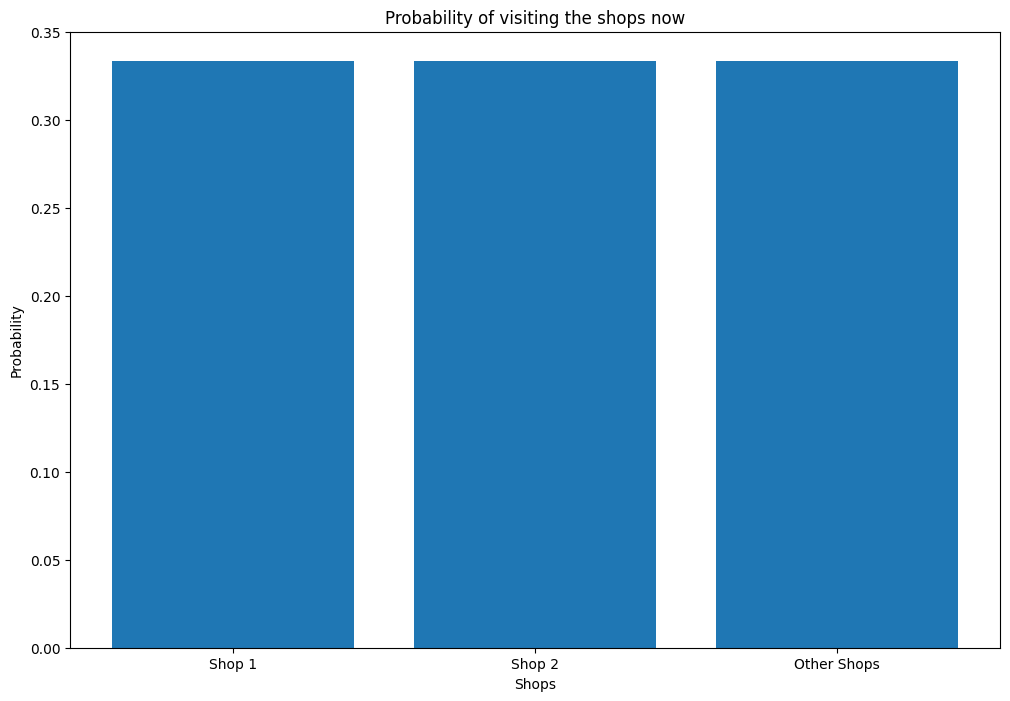

In [3]:
plt.figure(figsize=(12, 8))
plt.title("Probability of visiting the shops now")
pl = plt.bar(['Shop 1', 'Shop 2', 'Other Shops'], [shop1.p, shop2.p, shop_other.p])
plt.xlabel("Shops")
plt.ylabel("Probability")
plt.show()

In [4]:
#creating the simulation for the customer to visit the shops and get the reward
#  and update the probability
# now the customer will visit the shop for 1000 times and we will see how the probability 
# of visiting the shops changes over time
for i in range(10000):
    m=np.random.rand()
    if m<shop1.p:
        reward = shop1.reward()
        shop1.update_probability(reward)
    elif m<shop1.p + shop2.p: 
        reward = shop2.reward()
        shop2.update_probability(reward)
    else:
        reward = shop_other.reward()
        shop_other.update_probability(reward)
    # Normalize so probabilities sum to 1
    total = shop1.p + shop2.p + shop_other.p
    shop1.p /= total
    shop2.p /= total
    shop_other.p /= total

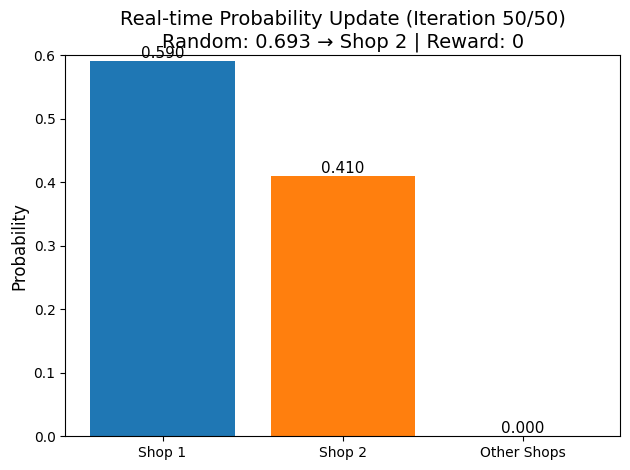


Final Probabilities after 50 iterations:
Shop 1: 0.5904
Shop 2: 0.4096
Other Shops: 0.0000


In [5]:
# Real-time visualization of probability updates - Growing in real-time
import matplotlib.pyplot as plt
from IPython.display import clear_output

probabilities_history = []

# Reset the shops to start fresh
shop1 = Shop(0.9)
shop2 = Shop(0.6)
shop_other = Shop(0.4)

for i in range(50):
    m = np.random.rand()
    
    # Choose shop based on probability and get reward
    if m < shop1.p:
        reward = shop1.reward()
        shop1.update_probability(reward)
        chosen_shop = "Shop 1"
    elif m < shop1.p + shop2.p:
        reward = shop2.reward()
        shop2.update_probability(reward)
        chosen_shop = "Shop 2"
    else:
        reward = shop_other.reward()
        shop_other.update_probability(reward)
        chosen_shop = "Other Shops"
    
    # Normalize probabilities to sum to 1
    total = shop1.p + shop2.p + shop_other.p
    shop1.p /= total
    shop2.p /= total
    shop_other.p /= total
    
    probabilities_history.append((shop1.p, shop2.p, shop_other.p))
    
    # Clear output and display updated plot every iteration
    clear_output(wait=True)
    
    fig, ax = plt.subplots()
    bars = ax.bar(['Shop 1', 'Shop 2', 'Other Shops'], 
                  [shop1.p, shop2.p, shop_other.p],
                  color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_ylabel("Probability", fontsize=12)
    ax.set_ylim(0, 0.6)
    ax.set_title(f"Real-time Probability Update (Iteration {i+1}/50)\nRandom: {m:.3f} → {chosen_shop} | Reward: {reward}", fontsize=14)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}', ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    import time
    time.sleep(0.5)  # Pause for 0.5 seconds between iterations

print("\nFinal Probabilities after 50 iterations:")
print(f"Shop 1: {shop1.p:.4f}")
print(f"Shop 2: {shop2.p:.4f}")
print(f"Other Shops: {shop_other.p:.4f}")

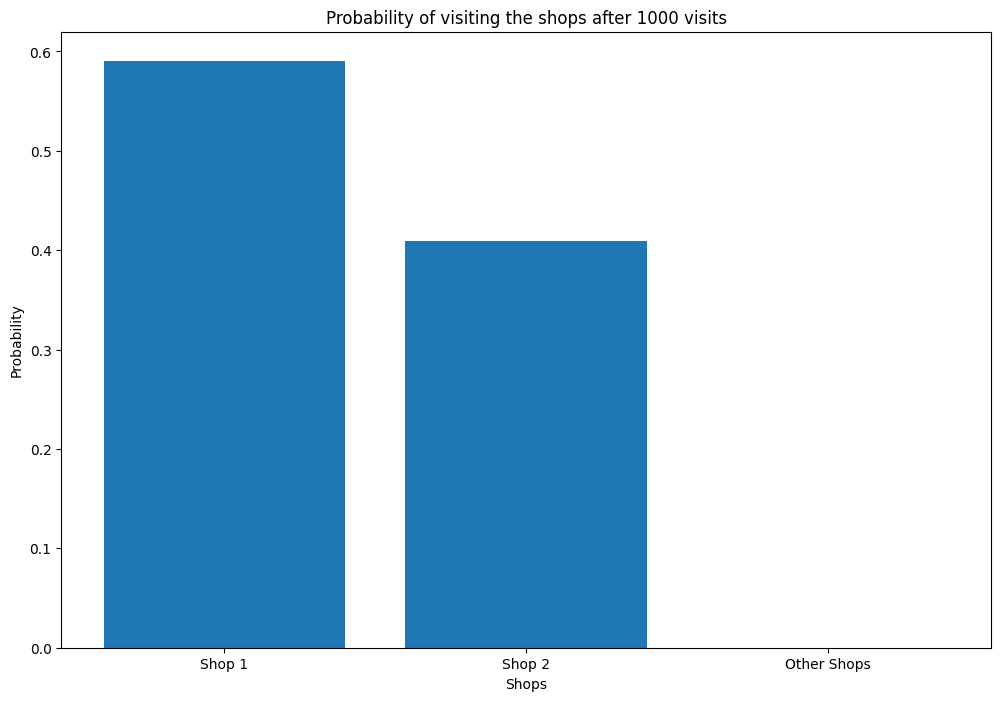

In [6]:
plt.figure(figsize=(12, 8))
plt.title("Probability of visiting the shops after 1000 visits")
pl = plt.bar(['Shop 1', 'Shop 2', 'Other Shops'], [shop1.p, shop2.p, shop_other.p])
plt.xlabel("Shops") 
plt.ylabel("Probability")
plt.show()